In [ ]:
# 1. 라이브러리 불러오기
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 2. 데이터 불러오기
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
data = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("데이터 확인")
print(data.head())

# 3. 라벨 숫자로 변환 (ham=0, spam=1)
encoder = LabelEncoder()
data['label'] = encoder.fit_transform(data['label'])

# 4. 데이터 분리
X = data['message'].astype(str)
y = data['label']

# 5. train/test 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. 텍스트를 숫자로 변환
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=1000,
    output_mode='int',
    output_sequence_length=50
)

vectorizer.adapt(X_train)

X_train = vectorizer(X_train)
X_test = vectorizer(X_test)

# 7. 모델 생성
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=1000, output_dim=16),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 8. 컴파일
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 9. 학습
print("모델 학습 시작")
model.fit(X_train, y_train, epochs=3)

# 10. 평가
loss, accuracy = model.evaluate(X_test, y_test)
print("최종 정확도:", accuracy)


데이터 확인
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
모델 학습 시작
Epoch 1/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8658 - loss: 0.3606
Epoch 2/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8598 - loss: 0.2913
Epoch 3/3
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8925 - loss: 0.2201
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9022 - loss: 0.2001
최종 정확도: 0.902242124080658


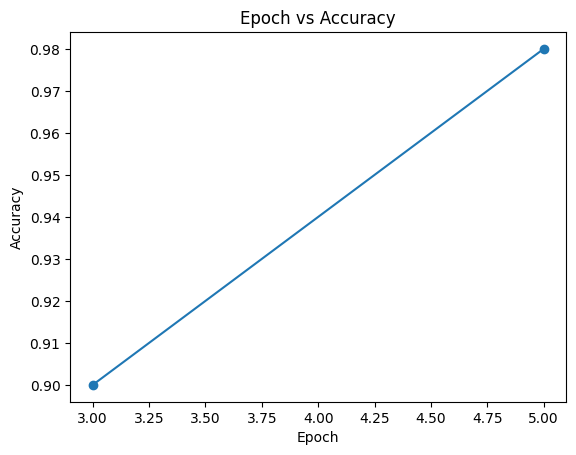

In [1]:
import matplotlib.pyplot as plt

epochs = [3, 5]
accuracy = [0.90, 0.98]

plt.plot(epochs, accuracy, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Epoch vs Accuracy")
plt.show()

In [ ]:
print("\n--- Epoch 5로 다시 실험 ---")

model.fit(X_train, y_train, epochs=5)

loss2, accuracy2 = model.evaluate(X_test, y_test)
print("Epoch 5 정확도:", accuracy2)


--- Epoch 5로 다시 실험 ---
Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9441 - loss: 0.1647
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9621 - loss: 0.1203
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9713 - loss: 0.0943
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9735 - loss: 0.0789
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9776 - loss: 0.0674
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9857 - loss: 0.0818
Epoch 5 정확도: 0.9856502413749695


In [ ]:
pred = model.predict(X_test[:5])

for i, p in enumerate(pred):
    print(f"문장 {i+1} 위험도: {p[0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
문장 1 위험도: 0.01
문장 2 위험도: 0.09
문장 3 위험도: 0.00
문장 4 위험도: 0.04
문장 5 위험도: 0.09
